https://arxiv.org/pdf/1705.08039

In [1]:
import torch
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [16]:
def hyperbolic_dist(u, v, eps=1e-8):
    diff = u - v
    return np.arccosh(1 + 2 * (diff.T @ diff)/((1-(u.T @ u)+eps)*(1-(v.T @ v)+eps)))

u = np.array([3, 2])
v = np.array([1, 4])

hyperbolic_dist(u, v)

0.4054651083998312

In [23]:
r = np.linspace(-3, 3, 20)
xx, yy = np.meshgrid(r, r)
D = np.vstack([xx.ravel(), yy.ravel()]).T

D.shape

(400, 2)

In [24]:
dists = np.array([[hyperbolic_dist(di, dj) for di in D] for dj in D])

dists.shape

C:\Users\janba\AppData\Local\Temp\ipykernel_38424\859598415.py:3: RuntimeWarning: invalid value encountered in arccosh
  return np.arccosh(1 + 2 * (diff.T @ diff)/((1-(u.T @ u)+eps)*(1-(v.T @ v)+eps)))


(400, 400)

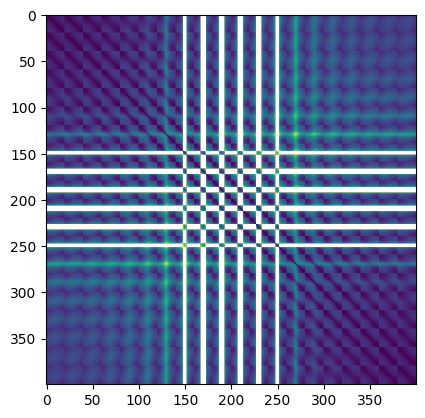

In [25]:
plt.imshow(dists)